# Projet Data Collection - Immobilier Sénégal
### Master 1 IA - DIT Dakar


## Installation des librairies

In [1]:
!pip install requests beautifulsoup4 pandas plotly ipywidgets



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Importation des librairies

In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
import plotly.express as px
from IPython.display import display, HTML
import ipywidgets as widgets


---
## PARTIE 1 : Scraping


### Choix du nombre de pages

In [7]:
# choisissez le nombre de pages a scraper
nb_pages = widgets.BoundedIntText(
    value=5,
    min=1,
    max=50,
    description="Nb pages :"
)

display(nb_pages)


BoundedIntText(value=5, description='Nb pages :', max=50, min=1)

In [8]:
# url du site
url_base = "https://sn.coinafrique.com/categorie/immobilier"

# header pour simuler un navigateur
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}


In [9]:
# fonction qui scrape une seule page
def scraper_page(numero_page):

    url = url_base + "?page=" + str(numero_page)

    try:
        reponse = requests.get(url, headers=headers, timeout=30)
    except Exception as e:
        print("erreur sur la page", numero_page, ":", e)
        return []

    soup = BeautifulSoup(reponse.text, "html.parser")
    annonces = soup.find_all("div", class_="col s6 m4 l3")

    liste = []

    for annonce in annonces:

        bien = {
            "prix": None,
            "description": None,
            "localisation": None,
            "type_de_bien": None,
            "nombre_pieces": None,
            "nombre_salle_de_bain": None,
            "superficie": None,
            "url": None
        }

        # recuperer le lien
        lien = annonce.find("a", href=True)
        if lien:
            href = lien["href"]
            if href.startswith("http"):
                bien["url"] = href
            else:
                bien["url"] = "https://sn.coinafrique.com" + href

        # recuperer le prix
        prix_tag = annonce.find(class_=re.compile(r"price|prix", re.I))
        if prix_tag:
            bien["prix"] = prix_tag.get_text(strip=True)

        # recuperer la description
        p_tag = annonce.find("p")
        if p_tag:
            bien["description"] = p_tag.get_text(strip=True)
            t = bien["description"].lower()
            if "villa" in t:
                bien["type_de_bien"] = "Villa"
            elif "appartement" in t:
                bien["type_de_bien"] = "Appartement"
            elif "terrain" in t:
                bien["type_de_bien"] = "Terrain"
            elif "maison" in t:
                bien["type_de_bien"] = "Maison"
            elif "studio" in t:
                bien["type_de_bien"] = "Studio"
            elif "bureau" in t:
                bien["type_de_bien"] = "Bureau"
            else:
                bien["type_de_bien"] = "Autre"

        # recuperer la localisation
        loc = annonce.find(class_=re.compile(r"location|localisation", re.I))
        if loc:
            bien["localisation"] = loc.get_text(strip=True)

        # recuperer superficie, pieces, sdb dans le texte
        texte = annonce.get_text(" ", strip=True)

        r1 = re.search(r"(\d+)\s*pieces?", texte, re.I)
        if r1:
            bien["nombre_pieces"] = int(r1.group(1))

        r2 = re.search(r"(\d+)\s*salle", texte, re.I)
        if r2:
            bien["nombre_salle_de_bain"] = int(r2.group(1))

        r3 = re.search(r"(\d+)\s*m2?", texte, re.I)
        if r3:
            bien["superficie"] = r3.group(1)

        if bien["url"]:
            liste.append(bien)

    return liste


### Lancement du scraping

In [10]:
# on recupere la valeur choisie dans le number_input
n = nb_pages.value

print("Nombre de pages a scraper :", n)

# on lance le scraping sur toutes les pages
tous_les_biens = []

for i in range(1, n + 1):
    print("scraping page", i, "/", n)
    biens = scraper_page(i)
    tous_les_biens.extend(biens)
    print(" ->", len(biens), "biens trouves")
    time.sleep(1)

print()
print("Total biens scrapes :", len(tous_les_biens))


Nombre de pages a scraper : 5
scraping page 1 / 5
 -> 84 biens trouves
scraping page 2 / 5
 -> 84 biens trouves
scraping page 3 / 5
 -> 84 biens trouves
scraping page 4 / 5
 -> 84 biens trouves
scraping page 5 / 5
 -> 84 biens trouves

Total biens scrapes : 420


In [11]:
# creation du dataframe
df = pd.DataFrame(tous_les_biens)

print("Dimensions :", df.shape)
print()
print("Valeurs manquantes :")
print(df.isnull().sum())


Dimensions : (420, 8)

Valeurs manquantes :
prix                      0
description               0
localisation              0
type_de_bien              0
nombre_pieces           419
nombre_salle_de_bain    420
superficie              375
url                       0
dtype: int64


In [12]:
# affichage du tableau
df.head(10)


,prix,description,localisation,type_de_bien,nombre_pieces,nombre_salle_de_bain,superficie,url
0,25 000 000CFA,25 000 000CFA,"location_onKeur Massar, Sénégal",Autre,NaN,None,23,https://sn.coinafrique.com/annonce/terrains/te...
1,25 000CFA,25 000CFA,"location_onSacré-Coeur, Dakar, Sénégal",Autre,NaN,None,33,https://sn.coinafrique.com/annonce/appartement...
2,350 000CFA,350 000CFA,"location_onSicap Liberté, Dakar, Sénégal",Autre,NaN,None,NaN,https://sn.coinafrique.com/annonce/appartement...
3,550 000CFA,550 000CFA,"location_onSicap Liberté, Dakar, Sénégal",Autre,NaN,None,NaN,https://sn.coinafrique.com/annonce/appartement...
4,700 000CFA,700 000CFA,"location_onMermoz-Sacré Coeur, Dakar, Sénégal",Autre,NaN,None,42,https://sn.coinafrique.com/annonce/appartement...
5,500 000CFA,500 000CFA,"location_onMermoz-Sacré Coeur, Dakar, Sénégal",Autre,NaN,None,43,https://sn.coinafrique.com/annonce/appartement...
6,310 000CFA,310 000CFA,"location_onAlmadies, Dakar, Sénégal",Autre,NaN,None,NaN,https://sn.coinafrique.com/annonce/appartement...
7,425 000CFA,425 000CFA,"location_onYoff, Dakar, Sénégal",Autre,NaN,None,51,https://sn.coinafrique.com/annonce/appartement...
8,250 000 000CFA,250 000 000CFA,"location_onMedina, Dakar, Sénégal",Autre,NaN,None,51,https://sn.coinafrique.com/annonce/immeubles/v...
9,105 000 000CFA,105 000 000CFA,"location_onSicap foire, Dakar, Sénégal",Autre,NaN,None,51,https://sn.coinafrique.com/annonce/villas/vent...


In [13]:
# sauvegarde en csv
df.to_csv("dataset_coinafrique.csv", index=False, encoding="utf-8-sig")
print("Dataset sauvegarde : dataset_coinafrique.csv")


Dataset sauvegarde : dataset_coinafrique.csv


---
## PARTIE 2 : Nettoyage et Visualisation


In [14]:
# nettoyage des prix
def convertir_prix(p):
    if pd.isna(p):
        return None
    p = re.sub(r"[^\d]", "", str(p))
    return float(p) if p else None

df["prix_num"] = df["prix"].apply(convertir_prix)
df["superficie"] = pd.to_numeric(df["superficie"], errors="coerce")

# suppression des doublons
df = df.drop_duplicates(subset=["url"])
df = df.reset_index(drop=True)

print("Nettoyage OK -", len(df), "biens")


Nettoyage OK - 420 biens


### Graphique 1 : Répartition des types de bien

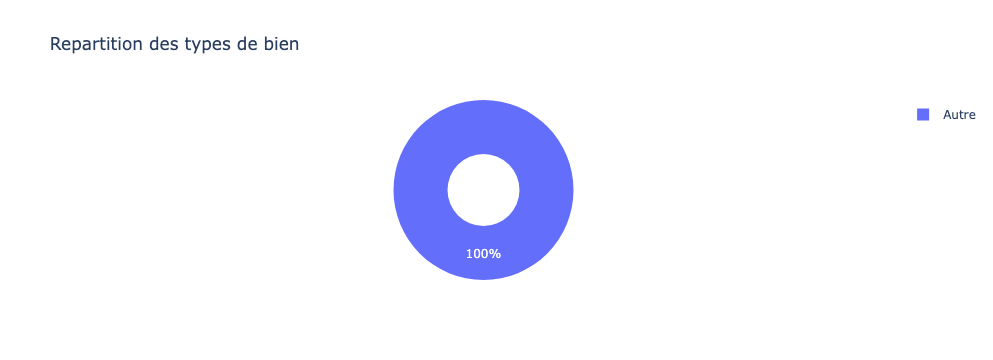

In [15]:
type_count = df["type_de_bien"].value_counts().reset_index()
type_count.columns = ["type_de_bien", "nombre"]

fig1 = px.pie(type_count, names="type_de_bien", values="nombre",
              title="Repartition des types de bien", hole=0.4)
fig1.show()


### Graphique 2 : Top 10 quartiers les plus chers

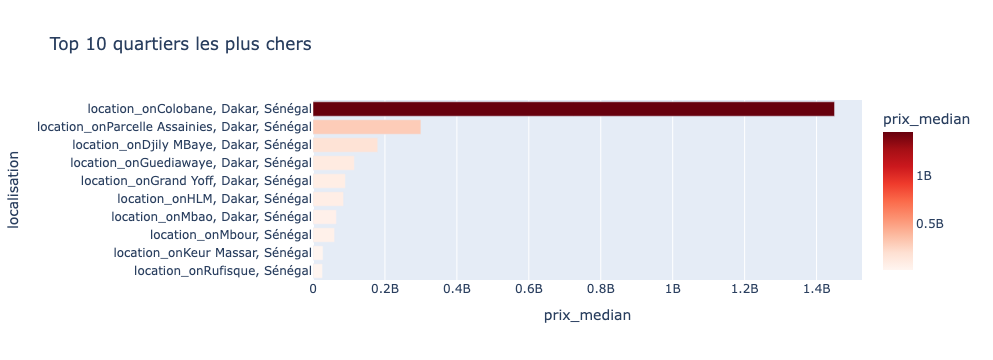

In [16]:
df2 = df.dropna(subset=["localisation", "prix_num"])
top = df2.groupby("localisation")["prix_num"].median().sort_values(ascending=False).head(10).reset_index()
top.columns = ["localisation", "prix_median"]

fig2 = px.bar(top, x="prix_median", y="localisation", orientation="h",
              title="Top 10 quartiers les plus chers", color="prix_median",
              color_continuous_scale="Reds")
fig2.update_layout(yaxis=dict(autorange="reversed"))
fig2.show()


### Graphique 3 : Nombre d'annonces par localisation

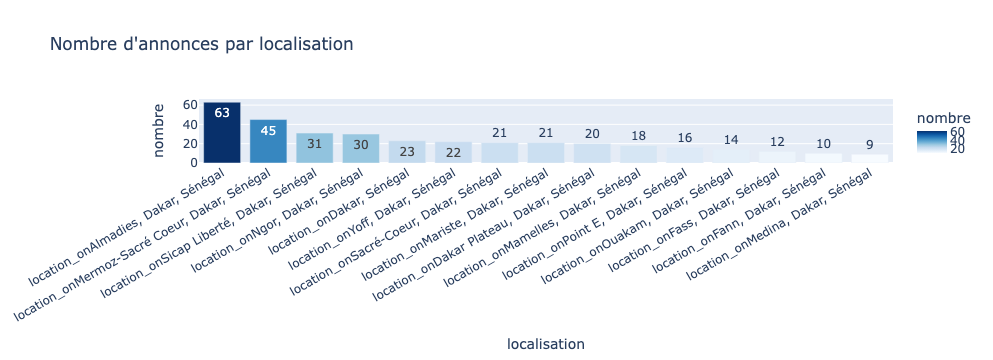

In [17]:
df3 = df.dropna(subset=["localisation"])
loc_count = df3["localisation"].value_counts().head(15).reset_index()
loc_count.columns = ["localisation", "nombre"]

fig3 = px.bar(loc_count, x="localisation", y="nombre",
              title="Nombre d'annonces par localisation", color="nombre",
              color_continuous_scale="Blues", text_auto=True)
fig3.update_layout(xaxis_tickangle=-30)
fig3.show()


### Graphique 4 : Distribution des prix

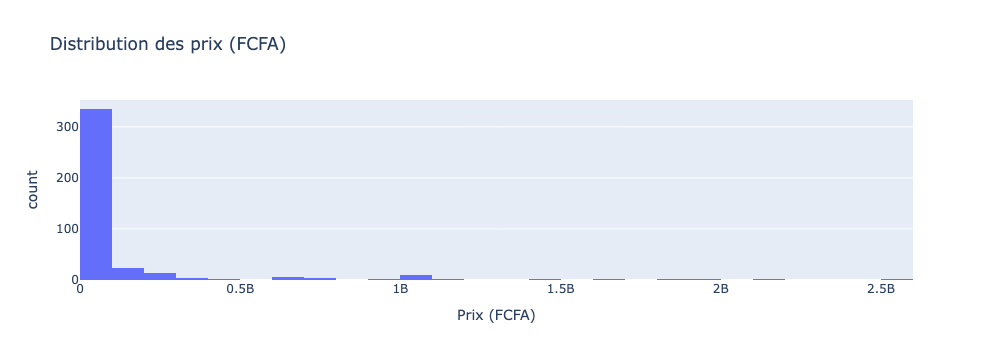

In [18]:
df4 = df.dropna(subset=["prix_num"])

fig4 = px.histogram(df4, x="prix_num", nbins=30,
                    title="Distribution des prix (FCFA)",
                    labels={"prix_num": "Prix (FCFA)"})
fig4.show()


---
## PARTIE 3 : Formulaire KoboToolbox

Remplacez le lien ci-dessous par votre lien Enketo KoboToolbox


In [19]:
# remplacez ce lien par votre vrai lien kobotoolbox
lien_kobo = "https://ee.kobotoolbox.org/x/iUKQhCaO"

# on affiche le formulaire avec un iframe
html_formulaire = f"""
<h3>Formulaire - Besoins Immobiliers</h3>
<a href="{lien_kobo}" target="_blank">
    <button style="
        background-color: #4CAF50;
        color: white;
        padding: 12px 24px;
        border: none;
        border-radius: 8px;
        font-size: 16px;
        cursor: pointer;">
        📋 Ouvrir le formulaire KoboToolbox
    </button>
</a>
"""

display(HTML(html_formulaire))


---
**Master 1 IA - Data Collection - DIT Dakar - Janvier 2026**
